In [1]:
import jax
import jax.numpy as jnp

In [2]:
print(jax.devices())
print(jax.default_backend())

## Check GPU check:
if jax.default_backend() != "gpu":
    raise RuntimeError(
        "This notebook is not running on GPU. "
        "In Colab, go to Runtime -> Change runtime type -> Hardware accelerator -> T4 GPU."
    )

[CudaDevice(id=0)]
gpu


In [ ]:
## JAX numpy arrays
x = jnp.array([1.0, 2.0, 3.0])
y = jnp.array([4.0, 5.0, 6.0])

z = x + y
d = jnp.dot(x, y)

print("x + y =", z)
print("x dot y =", d)
print("z device:", z.devices())
print("d device:", d.devices())

x + y = [5. 7. 9.]
x dot y = 32.0
z device: {CudaDevice(id=0)}
d device: {CudaDevice(id=0)}


In [ ]:
## JAX arrays are immutable. So we need to do this:
x_new = x.at[1].set(10.0)
x_new

Array([ 1., 10.,  3.], dtype=float32)

# compiling scientific Python

for a function
$$
f(x) = \frac{1}{1+e^{-x}}
$$
the `JAX` compiled function should look like:

`f_jit = jax.jit(f)`

In [ ]:
import time


def sigmoid(x):
    return 1.0 / (1.0 + jnp.exp(-x)) ## remeber using jnp

sigmoid_jit = jax.jit(sigmoid) ## remeber using jit

In [ ]:
x = jnp.linspace(-10, 10, 5000000)

# First call includes compilation
y = sigmoid_jit(x)
y.block_until_ready()

# Second call measures compiled execution
start = time.perf_counter()
y = sigmoid_jit(x)
y.block_until_ready()
end = time.perf_counter()

print("Output shape:", y.shape)
print("Output device:", y.devices())
print("Compiled execution time:", end - start, "seconds")

Output shape: (5000000,)
Output device: {CudaDevice(id=0)}
Compiled execution time: 0.000499737999973604 seconds


### The first time we call a jitted function, JAX compiles it. That first call may be slow. After compilation, the same function can run much faster.

### JAX’s `jax.jit()` performs just-in-time compilation so a Python function can execute efficiently using XLA. See the [link](https://docs.jax.dev/en/latest/jit-compilation.html)

## In JAX, random numbers are generated from a global random state. Instead, you explicitely create and pass a random key.

In [ ]:
## In numpy we do

import numpy as np

x = np.random.normal(size=5)
y = np.random.normal(size=5)

In [ ]:
x

array([-1.46708396e+00, -7.92612588e-01,  1.72017256e+00,  1.29933429e-03,
       -2.37248966e-02])

In [ ]:
y

array([-0.08830962,  0.94577637,  0.26908473, -0.367276  , -1.09411917])

In [ ]:
## In JAX we do

key = jax.random.key(38) ## key controls the randomness.

x = jax.random.normal(key, shape=(5,))
x

## Every random operation needs a key

Array([-0.55540335, -1.4380941 ,  0.14563978,  1.5643644 , -0.41533524],      dtype=float32)

## Important point: reusing the same key gives the same result

In [ ]:
key = jax.random.key(31)

x = jax.random.normal(key, shape=(5,))
y = jax.random.normal(key, shape=(5,))

print(x)
print(y)

[ 1.459392   -0.27659053  0.11213937 -1.8139102  -0.713337  ]
[ 1.459392   -0.27659053  0.11213937 -1.8139102  -0.713337  ]


In [ ]:
## So in JAX, you should not reuse the same key when you want new random numbers.

key = jax.random.key(31)

key, subkey1 = jax.random.split(key)
print(subkey1)
x = jax.random.normal(subkey1, shape=(5,))

key, subkey2 = jax.random.split(key)
y = jax.random.normal(subkey2, shape=(5,))

print(x)
print(y)

Array((), dtype=key<fry>) overlaying:
[3495797044 3024489638]
[ 0.05312927  0.7549298   1.282814    0.5354176  -1.7962769 ]
[ 0.15926148 -1.4179375  -0.456486    0.89446175 -0.05645273]


## Suppose we want random external input currents for neurons

$$
I_i^{\text ext} \sim \mathrm{N}(\mu, \sigma^2)
$$


In [ ]:
## we can use JAX as

key = jax.random.key(42)

N = 1000
mu = 2.4
sigma = 0.2

key, subkey = jax.random.split(key)

I_ext = mu + sigma * jax.random.normal(subkey, shape=(N,))

print(I_ext.shape) ## This creates random input currents for 1000 neurons.

(1000,)


## TIming GPU code correctly

### On a GPU, Python may only send the computation to the GPU and continue immediately. The actual computation may still be running.

### Therefore, to measure the real runtime, we need to wait until the GPU finishes

In [ ]:
## Let's use it to do simple matrix multiplication

import time

key = jax.random.key(0)
key_A, key_B = jax.random.split(key)

A = jax.random.normal(key_A, shape=(4000, 4000))
B = jax.random.normal(key_B, shape=(4000, 4000))

@jax.jit
def matmul(A, B):
    return A @ B

# Warm up / compile
C = matmul(A, B)
C.block_until_ready()

# Correct timing
start = time.perf_counter()
C = matmul(A, B)
C.block_until_ready()
end = time.perf_counter()

print("Device:", C.devices())
print("Time:", end - start, "seconds")

Device: {CudaDevice(id=0)}
Time: 0.04710766399989552 seconds


## Vectorise using `vmap()`

In [ ]:
key = jax.random.key(22)

key, subkey = jax.random.split(key)
I_ext = jax.random.normal(subkey, shape=(1000,)) * 0.2 + 2.4

print("External input shape:", I_ext.shape)
print("Device:", I_ext.devices())

def firing_rate(I):
    return 1.0 / (1.0 + jnp.exp(-5.0 * (I - 2.0)))

firing_rate_many = jax.jit(jax.vmap(firing_rate))

rates = firing_rate_many(I_ext)
rates.block_until_ready()

print("Rates shape:", rates.shape)
print("Rates device:", rates.devices())

External input shape: (1000,)
Device: {CudaDevice(id=0)}
Rates shape: (1000,)
Rates device: {CudaDevice(id=0)}


## Pairwise distance on GPU

Let's say for a neural activity data $X \in \mathbb{R}^{N \times T}$,

we want to compute the pairwise distance
$$
D_{ij} = \|X_i -X_j \|^2 = \|X_i\|^2 + \|X_j\|^2 - 2X_iX_j^T.
$$

In [ ]:
## Lets do this in JAX

@jax.jit
def pairwise_squared_distances(X):
    norms = jnp.sum(X**2, axis=1, keepdims=True)
    D = norms + norms.T - 2.0 * (X @ X.T)
    return D

key = jax.random.key(123)

N = 2000
T = 300

X = jax.random.normal(key, shape=(N, T))

# Compile
D = pairwise_squared_distances(X)
D.block_until_ready()

# Time
start = time.perf_counter()
D = pairwise_squared_distances(X)
D.block_until_ready()
end = time.perf_counter()

print("X shape:", X.shape)
print("D shape:", D.shape)
print("D device:", D.devices())
print("Time:", end - start, "seconds")

X shape: (2000, 300)
D shape: (2000, 2000)
D device: {CudaDevice(id=0)}
Time: 0.001527637999970466 seconds


## Lets do LIF neuron with reset

$$
\tau_m \frac{dV_i}{dt}
=
-\left(V_i - V_{\mathrm{rest}}\right)
+
R I_i(t)
$$

where $$ I_i(t) = I_i^{\mathrm{ext}} + \eta_i(t)$$

and the noise is $$ \eta_i(t) \sim \mathrm{N}(0, \sigma_{\eta}^{2})$$

The external input current is

$$
I_i^{\mathrm{ext}} \sim \mathrm{N}(\mu_I, \sigma_I^2).
$$

We utilise Euler discretisation

$$
V_i(t+\Delta t)
=
V_i(t)
+
\Delta t
\frac{
-\left(V_i(t)-V_{\mathrm{rest}}\right)
+
R I_i(t)
}
{\tau_m}.
$$

Spike condition:

$$
s_i(t)
=
\begin{cases}
1, & V_i(t) \geq V_{\mathrm{th}},\\
0, & V_i(t) < V_{\mathrm{th}},
\end{cases}
$$

and the reset rule is
$$
\text{if } s_i(t)=1,
\qquad
V_i(t) \leftarrow V_{\mathrm{reset}}.
$$




In [ ]:
## Let's simulate


@partial(jax.jit, static_argnames=("n_steps",))
## partial is used because we want to decorate the function with jax.jit
## while passing extra options.
def simulate_lif_population(key, I_ext, n_steps=5000):
    dt = 0.1
    tau_m = 20.0
    V_rest = -65.0
    V_reset = -65.0
    V_th = -50.0
    R = 10.0

    N = I_ext.shape[0]

    V0 = jnp.ones(N) * V_rest

    key_noise = key
    noise = 0.2 * jax.random.normal(key_noise, shape=(n_steps, N))

    def step(V, eta):
        I_t = I_ext + eta

        dVdt = (-(V - V_rest) + R * I_t) / tau_m
        V_new = V + dt * dVdt

        spikes = V_new >= V_th
        V_new = jnp.where(spikes, V_reset, V_new)

        return V_new, spikes.astype(jnp.float32)

    V_final, spikes = jax.lax.scan(step, V0, noise)

    return spikes

In [ ]:
key = jax.random.key(42)

N = 5000
I_ext = jnp.ones(N) * 2.3

spikes = simulate_lif_population(key, I_ext, n_steps=5000)
spikes.block_until_ready()

print("Spikes shape:", spikes.shape)
print("Spikes device:", spikes.devices())
print("Mean spike probability:", spikes.mean())

Spikes shape: (5000, 5000)
Spikes device: {CudaDevice(id=0)}
Mean spike probability: 0.0046


### Visualize spike activity

We can visualize the spike activity of the neuronal population as a heatmap, where each row represents a neuron and each column represents a time step. A bright spot indicates a spike at that particular time for that neuron.

/tmp/ipykernel_3480/1283884696.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


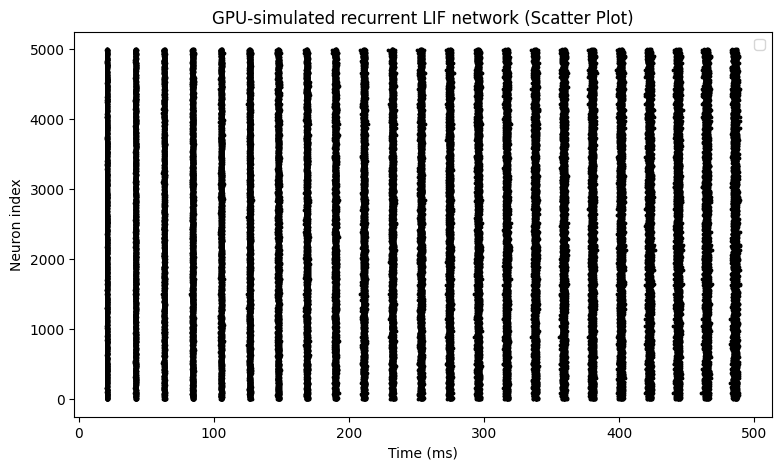

In [ ]:
import numpy as np

spikes_np = np.array(spikes)  # time × neurons
dt = 0.1
time_axis = np.arange(spikes_np.shape[0]) * dt

time_ids, neuron_ids = np.where(spikes_np == 1)

plt.figure(figsize=(9, 5))
plt.scatter(time_axis[time_ids], neuron_ids, s=3, color="black") # Increased marker size
plt.xlabel("Time (ms)")
plt.ylabel("Neuron index")
plt.title("GPU-simulated recurrent LIF network (Scatter Plot)")
plt.legend()
plt.show()

## Lets do a recurrent spiking neural network on a GPU

The recurrent input is

$$
I_i(t)
=
I_i^{\mathrm{ext}}
+
I_i^{\mathrm{syn}}(t), \\
I_i^{\mathrm{syn}}(t)
=
\sum_{j=1}^{N}
W_{ij}s_j(t)
$$

Voltage update:

$$
V_i(t+\Delta t)
=
V_i(t)
+
\Delta t
\frac{
-\left(V_i(t)-V_{\mathrm{rest}}\right)
+
R I_i(t)
}
{\tau_m}
$$


In [ ]:
from functools import partial
import jax
import jax.numpy as jnp

if jax.default_backend() != "gpu":
    raise RuntimeError("GPU not detected. Please enable GPU in Colab.")

@partial(jax.jit, static_argnames=("N", "n_steps"))
def simulate_recurrent_lif_network_gpu(
    key,
    N=1000,
    frac_E=0.8,
    n_steps=5000,
    dt=0.1,
    tau_m=20.0,
    V_rest=-65.0,
    V_reset=-65.0,
    V_th=-50.0,
    R=10.0,
    I_ext_mean=2.4,
    I_ext_std=0.2,
    p_connect=0.05,
    w_E=0.4,
    w_I=-1.5
):
    key_mask, key_input, key_voltage = jax.random.split(key, 3)

    N_E = int(frac_E * N)

    # Random connectivity mask
    mask = jax.random.uniform(key_mask, shape=(N, N)) < p_connect
    mask = mask.at[jnp.diag_indices(N)].set(False)

    # W[i, j] = effect of neuron j on neuron i
    W_E = jnp.ones((N, N_E)) * w_E
    W_I = jnp.ones((N, N - N_E)) * w_I
    W = jnp.concatenate([W_E, W_I], axis=1)
    W = W * mask

    # External input
    I_ext = I_ext_mean + I_ext_std * jax.random.normal(key_input, shape=(N,))

    # Initial state
    V0 = V_rest + 2.0 * jax.random.normal(key_voltage, shape=(N,))
    syn_input0 = jnp.zeros(N)

    def step(carry, _):
        V, syn_input = carry

        I_total = I_ext + syn_input

        dVdt = (-(V - V_rest) + R * I_total) / tau_m
        V_new = V + dt * dVdt

        spikes = V_new >= V_th
        V_new = jnp.where(spikes, V_reset, V_new)

        # Recurrent input for next time step
        syn_input_new = W @ spikes.astype(jnp.float32)

        new_carry = (V_new, syn_input_new)
        output = spikes.astype(jnp.float32)

        return new_carry, output

    final_state, spikes = jax.lax.scan(
        step,
        (V0, syn_input0),
        xs=None,
        length=n_steps
    )

    # spikes has shape: time × neurons
    return spikes, W, N_E

In [ ]:
key = jax.random.key(7)

# Compile
spikes, W, N_E = simulate_recurrent_lif_network_gpu(
    key,
    N=1000,
    n_steps=5000
)
spikes.block_until_ready()

# Time compiled run
start = time.perf_counter()

spikes, W, N_E = simulate_recurrent_lif_network_gpu(
    key,
    N=1000,
    n_steps=5000
)
spikes.block_until_ready()

end = time.perf_counter()

print("Spikes shape:", spikes.shape)
print("Spikes device:", spikes.devices())
print("W device:", W.devices())
print("Number of excitatory neurons:", N_E)
print("Compiled runtime:", end - start, "seconds")

Spikes shape: (5000, 1000)
Spikes device: {CudaDevice(id=0)}
W device: {CudaDevice(id=0)}
Number of excitatory neurons: 800
Compiled runtime: 0.15755024199961554 seconds


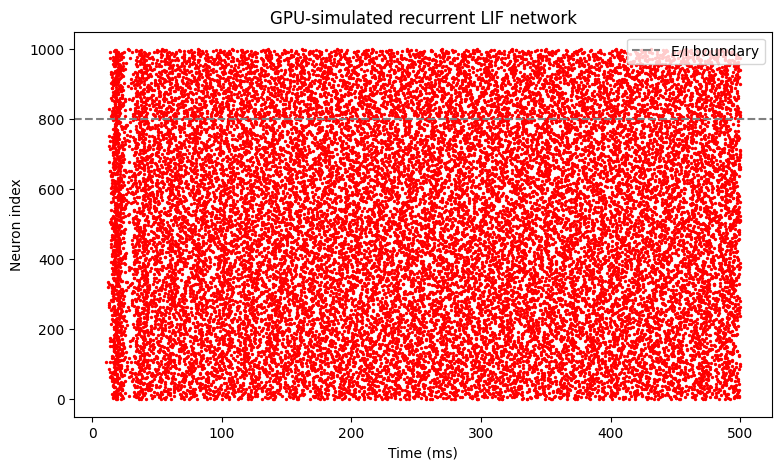

In [ ]:
spikes_np = np.array(spikes)  # time × neurons
dt = 0.1
time_axis = np.arange(spikes_np.shape[0]) * dt

time_ids, neuron_ids = np.where(spikes_np == 1)

plt.figure(figsize=(9, 5))
plt.scatter(time_axis[time_ids], neuron_ids, s=2, color="red")
plt.axhline(N_E, linestyle="--", color="gray", label="E/I boundary")
plt.xlabel("Time (ms)")
plt.ylabel("Neuron index")
plt.title("GPU-simulated recurrent LIF network")
plt.legend()
plt.show()

## Automating Differentiation using `jax.grad()`

In [ ]:
def L(w):
    return (w - 2.0)**2

grad_L = jax.grad(L)

w = 5.0

print("L(w) =", L(w))
print("dL/dw =", grad_L(w))

L(w) = 9.0
dL/dw = 6.0


## Fitting a simple linear model

suppose we have data $$ y=wx $$

and we want to learn $w$.

Lets the mean squared error be

$$
L(w) = \frac{1}{N} \sum_{i=1}^N (y_i -wx_i)^2
$$

JAX can compute $$\frac{dL}{dw}.$$

In [ ]:
x = jnp.array([1.0, 2.0, 3.0, 4.0])
y = jnp.array([2.0, 4.0, 6.0, 8.0])

def loss(w):
    y_pred = w * x
    return jnp.mean((y - y_pred)**2)

grad_loss = jax.grad(loss)

w = 0.0
learning_rate = 0.1

for step in range(20):
    g = grad_loss(w)
    w = w - learning_rate * g

    if step % 5 == 0:
        print(step, "w =", w, "loss =", loss(w))

0 w = 3.0 loss = 7.5
5 w = 1.96875 loss = 0.0073242188
10 w = 2.0009766 loss = 7.1525574e-06
15 w = 1.9999695 loss = 6.9849193e-09


Here JAX the gradient automatically and we update

$$
w \leftarrow w - \alpha \frac{dL}{dw}
$$



In [ ]:
@jax.jit
def loss(w, x, y):
    y_pred = w * x
    return jnp.mean((y - y_pred)**2)

grad_loss = jax.jit(jax.grad(loss))

x = jnp.linspace(0, 10, 1_000_000)
y = 2.0 * x

w = 0.0
learning_rate = 0.01

for step in range(500):
    g = grad_loss(w, x, y)
    w = w - learning_rate * g

print("Learned w:", w)
print("Device:", x.devices())

Learned w: 2.0
Device: {CudaDevice(id=0)}


## Neuroscience example

## Neuroscience example

Suppose a firing-rate model is:

$$
r(I; a, h)
=
\frac{1}
{1+\exp[-a(I-h)]}.
$$

Here:

$$
a
$$

is the gain, and

$$
h
$$

is the threshold.

Suppose we observe target firing rates $r_{\mathrm{target}}$. We can fit $a$ and $h$ by minimising:

$$
L(a,h)
=
\frac{1}{N}
\sum_{i=1}^{N}
\left[
r_{\mathrm{target},i}
-
r(I_i; a, h)
\right]^2.
$$

In [ ]:


def sigmoid_rate(I, params):
    a, h = params
    return 1.0 / (1.0 + jnp.exp(-a * (I - h)))

def loss(params, I, r_target):
    r_pred = sigmoid_rate(I, params)
    return jnp.mean((r_target - r_pred)**2)

grad_loss = jax.jit(jax.grad(loss))

I = jnp.linspace(0, 5, 1000)

true_params = jnp.array([5.0, 2.0])
r_target = sigmoid_rate(I, true_params)

params = jnp.array([1.0, 1.0])
learning_rate = 0.1

for step in range(10000):
    g = grad_loss(params, I, r_target)
    params = params - learning_rate * g

print("Estimated gain a:", params[0])
print("Estimated threshold h:", params[1])
print("Device:", params.devices())

Estimated gain a: 4.289187
Estimated threshold h: 1.9999981
Device: {CudaDevice(id=0)}


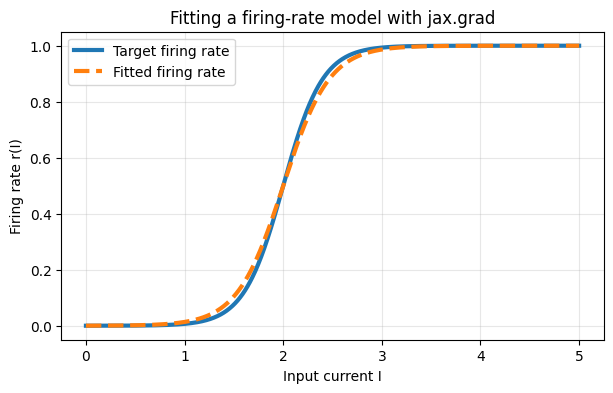

Estimated gain a: 4.289186954498291
Estimated threshold h: 1.9999980926513672


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Convert JAX arrays to NumPy for plotting
I_np = np.array(I)
r_target_np = np.array(r_target)

# Fitted prediction using learned params
r_fitted = sigmoid_rate(I, params)
r_fitted_np = np.array(r_fitted)

plt.figure(figsize=(7, 4))

plt.plot(I_np, r_target_np, linewidth=3, label="Target firing rate")
plt.plot(I_np, r_fitted_np, linestyle="--", linewidth=3, label="Fitted firing rate")

plt.xlabel("Input current I")
plt.ylabel("Firing rate r(I)")
plt.title("Fitting a firing-rate model with jax.grad")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

print("Estimated gain a:", float(params[0]))
print("Estimated threshold h:", float(params[1]))

## Independent simulations on an $N\times N$ grid

## Let the grid be of parameters $(w, I) \in \mathbb{R}^{N \times N}$, and we plot the $r_{\rm final}(w, I)$

In [3]:
import jax
import jax.numpy as jnp

print("JAX devices:", jax.devices())
print("Default backend:", jax.default_backend())

if jax.default_backend() != "gpu":
    raise RuntimeError(
        "GPU not detected. In Colab, go to Runtime → Change runtime type → GPU."
    )

JAX devices: [CudaDevice(id=0)]
Default backend: gpu


In [4]:
import jax
import jax.numpy as jnp
from functools import partial
import time

In [9]:
def sigmoid(x, a=5.0, h=1.0):
    return 1.0 / (1.0 + jnp.exp(-a * (x - h)))

def simulate_one_parameter_pair(w, I, n_steps=1000, dt=0.01, tau=1.0):
    """
    Simulate one firing-rate model for one pair of parameters (w, I).
    """

    r0 = 0.1

    def step(r, _):
        drdt = (-r + sigmoid(w * r + I)) / tau
        r_new = r + dt * drdt
        return r_new, r_new

    r_final, r_trace = jax.lax.scan(step, r0, xs=None, length=n_steps)

    return r_final

### `jax.lax.scan()` is JAX’s compiled loop function. It is useful when you want to repeatedly apply the same update rule many times, especially inside jax.jit and on a GPU.

### `xs=None` means no external sequence being passed into the loop.

In [13]:
## vectorise over the NxN grid

N_grid = 1000

w_values = jnp.linspace(0.0, 5.0, N_grid)
I_values = jnp.linspace(-2.0, 3.0, N_grid)

W_grid, I_grid = jnp.meshgrid(w_values, I_values, indexing="ij")

print("W_grid shape:", W_grid.shape)
print("I_grid shape:", I_grid.shape)

W_grid shape: (1000, 1000)
I_grid shape: (1000, 1000)


In [14]:
## GPU parallel computation

@partial(jax.jit, static_argnames=("n_steps",))
def simulate_grid(W_grid, I_grid, n_steps=1000):
    """
    Run independent simulations over all points in an N x N parameter grid.
    """

    simulate_vectorised = jax.vmap(
        jax.vmap(
            lambda w, I: simulate_one_parameter_pair(
                w, I, n_steps=n_steps
            ),
            in_axes=(0, 0)
        ),
        in_axes=(0, 0)
    )

    R_final_grid = simulate_vectorised(W_grid, I_grid)

    return R_final_grid

In [15]:
## time the simulation

# Compile and warm up
R_final_grid = simulate_grid(W_grid, I_grid, n_steps=1000)
R_final_grid.block_until_ready()

# Timed run
start = time.perf_counter()

R_final_grid = simulate_grid(W_grid, I_grid, n_steps=1000)
R_final_grid.block_until_ready()

end = time.perf_counter()

print("Output shape:", R_final_grid.shape)
print("Output device:", R_final_grid.devices())
print("Runtime:", end - start, "seconds")

Output shape: (1000, 1000)
Output device: {CudaDevice(id=0)}
Runtime: 0.07182126099996822 seconds


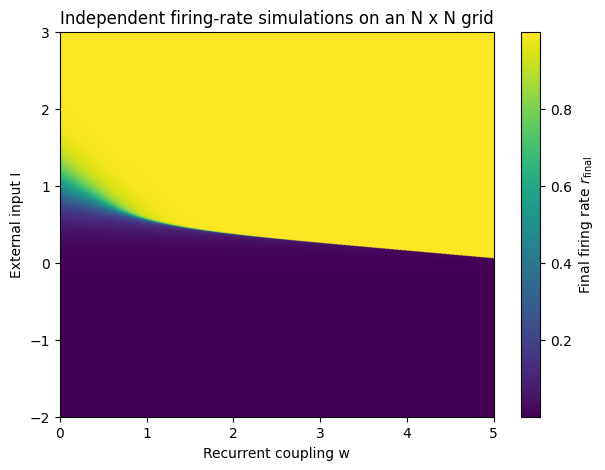

In [16]:
import numpy as np
import matplotlib.pyplot as plt

R_np = np.array(R_final_grid)
w_np = np.array(w_values)
I_np = np.array(I_values)

plt.figure(figsize=(7, 5))

plt.imshow(
    R_np.T,
    origin="lower",
    aspect="auto",
    extent=[w_np.min(), w_np.max(), I_np.min(), I_np.max()]
)

plt.colorbar(label=r"Final firing rate $r_{\mathrm{final}}$")
plt.xlabel("Recurrent coupling w")
plt.ylabel("External input I")
plt.title("Independent firing-rate simulations on an N x N grid")

plt.show()